In [110]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
import seaborn as sns
from matplotlib.patches import Patch

# Global font: larger, bold Times New Roman
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.serif': ['Times New Roman']
})
plt.rcParams['figure.constrained_layout.use'] = True

# Load overhead benchmark CSVs (search recursively)
csv_files = sorted(Path('../Benchmark/overhead_results').glob('bench_overhead_*.csv'))
if not csv_files:
    raise FileNotFoundError('No bench_overhead_*.csv found in project.')
frames = []
for fp in csv_files:
    df = pd.read_csv(fp)
    df['source'] = str(fp)
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
# enforce dtypes
if 'size' in data.columns:
    data['size'] = data['size'].astype(int)
# sanitize
data['metric'] = data['metric'].astype(str)
data


,approach,query,size,metric,mean_ms,std_ms,source
0,baseline,contact_valid,100,access,5.233754,0.159522,../Benchmark/overhead_results/bench_overhead_1...
1,baseline,contact_valid,100,compute,0.003425,0.000336,../Benchmark/overhead_results/bench_overhead_1...
2,escrow,contact_valid,100,access,5.474558,0.157024,../Benchmark/overhead_results/bench_overhead_1...
3,escrow,contact_valid,100,compute,0.003262,0.000419,../Benchmark/overhead_results/bench_overhead_1...
4,baseline,photo_transform,100,access,5.738996,0.420547,../Benchmark/overhead_results/bench_overhead_1...
5,baseline,photo_transform,100,compute,22.409854,0.493259,../Benchmark/overhead_results/bench_overhead_1...
6,escrow,photo_transform,100,access,5.824733,0.326597,../Benchmark/overhead_results/bench_overhead_1...
7,escrow,photo_transform,100,compute,23.014050,0.632850,../Benchmark/overhead_results/bench_overhead_1...
8,baseline,location_weather,0,access,0.052446,0.070478,../Benchmark/overhead_results/bench_overhead_1...
9,baseline,location_weather,0,compute,46.692838,1.402985,../Benchmark/overhead_results/bench_overhead_1...


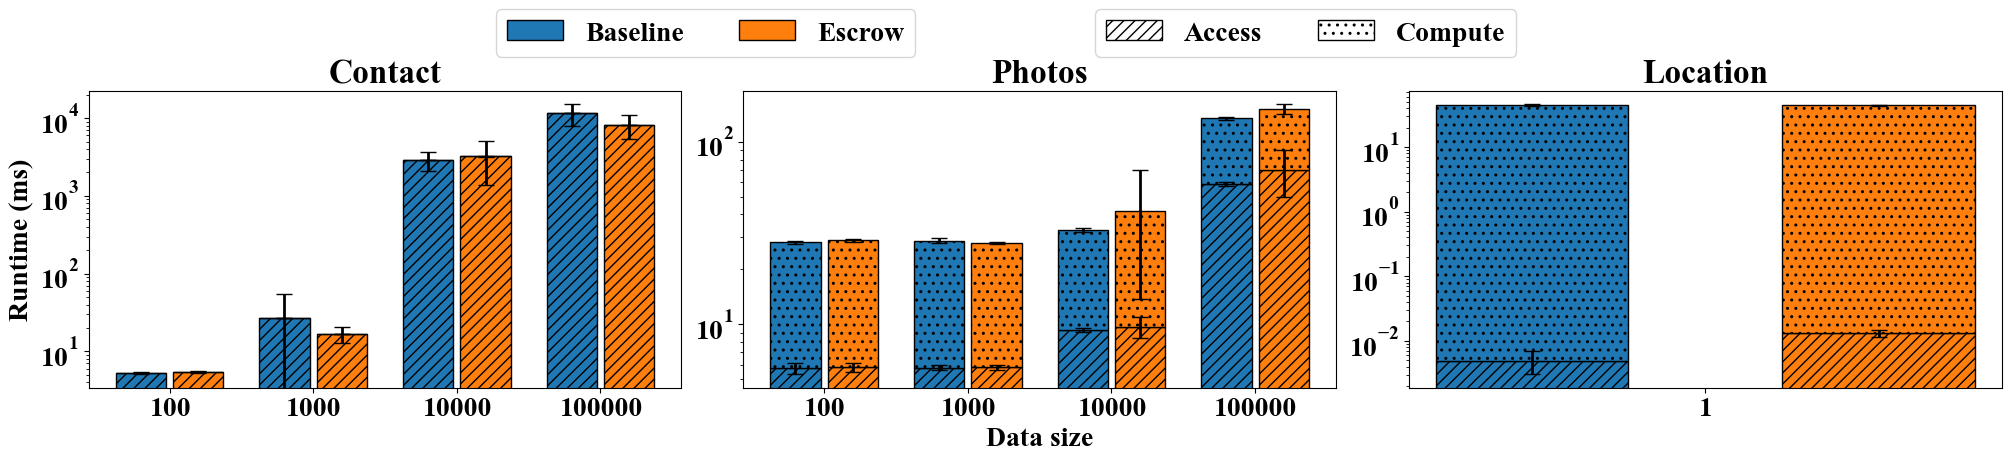

In [111]:
# Stacked bar plots: access + compute per approach
from math import sqrt


queries = {
    'contact_valid': 'Contact',
    'photo_transform': 'Photos',
    'location_weather': 'Location'
}
approaches = list(data['approach'].unique())
# color map for approaches
approach_colors = {
    'escrow': '#ff7f0e',
    'baseline': '#1f77b4'  
}
# hatches for metrics
metric_hatch = {
    'access': '///',
    'compute': '..'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=False)
# plt.subplots_adjust(top=0.78, wspace=0.25)

for ax, (q, title) in zip(axes, queries.items()):
    is_loc_plot = (title == 'Location')
    plot_df = data[(data['query'] == q)].copy()
    if is_loc_plot:
        # pick a single file's results for location; choose the first file alphabetically
        # first_src = plot_df['source'].sort_values().iloc[0]
        plot_df = plot_df[(plot_df['source'] == '../Benchmark/overhead_results/bench_overhead_1000.csv')]
        plot_df['size_str'] = '1'
    else:
        plot_df['size_str'] = plot_df['size'].astype(str)

    sizes = list(plot_df['size_str'].unique())
    sizes.sort(key=lambda s: int(s) if s.isdigit() else 0)

    width = 0.35
    x = np.arange(len(sizes))
    for i, approach in enumerate(approaches):
        color = approach_colors.get(approach, None)
        da = plot_df[(plot_df['approach'] == approach) & (plot_df['metric'] == 'access')]
        dc = plot_df[(plot_df['approach'] == approach) & (plot_df['metric'] == 'compute')]
        mean_a = [da[da['size_str']==s]['mean_ms'].iloc[0] if (da['size_str']==s).any() else 0 for s in sizes]
        std_a   = [da[da['size_str']==s]['std_ms'].iloc[0] if (da['size_str']==s).any() else 0 for s in sizes]
        mean_c = [dc[dc['size_str']==s]['mean_ms'].iloc[0] if (dc['size_str']==s).any() else 0 for s in sizes]
        std_c   = [dc[dc['size_str']==s]['std_ms'].iloc[0] if (dc['size_str']==s).any() else 0 for s in sizes]

        offset = (i - (len(approaches)-1)/2) * (width + 0.05)
        if plot_df['query'].iloc[0] == 'location_weather':
            width = 0.1
            offset = (i - (len(approaches)-1)/2) * (width + 0.08)
        
        bars_a = ax.bar(x + offset, mean_a, width, color=color, hatch=metric_hatch['access'], edgecolor='black')
        # error bars for access segment (on its top)
        ax.errorbar(x + offset, mean_a, yerr=std_a, fmt='none', ecolor='black', capsize=6, elinewidth=2)
        # stacked compute segment
        bars_c = ax.bar(x + offset, mean_c, width, bottom=mean_a, color=color, hatch=metric_hatch['compute'], edgecolor='black')
        # error bars for compute segment (on top of stacked bar)
        ax.errorbar(x + offset, np.array(mean_a) + np.array(mean_c), yerr=std_c, fmt='none', ecolor='black', capsize=6, elinewidth=2)

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(sizes)
    if title == 'Photos':
        ax.set_xlabel('Data size')
    ax.tick_params(axis='x', which='major')

    ax.set_yscale('log')

axes[0].set_ylabel('Runtime (ms)', fontweight='bold')

# Legends: place above subplot titles at the very top corners
approach_handles = [Patch(facecolor=approach_colors[a], edgecolor='black', label=a.capitalize()) for a in approaches]
metric_handles = [Patch(facecolor='white', edgecolor='black', hatch=metric_hatch[m], label=m.capitalize()) for m in ['access','compute']]
fig.legend(handles=approach_handles, loc='upper center', ncol=2, bbox_to_anchor=(0.35, 1.15))
fig.legend(handles=metric_handles, loc='upper center', ncol=2, bbox_to_anchor=(0.65, 1.15))

fig_name = f"figures/overhead/overhead.pdf"
plt.savefig(fig_name, bbox_inches='tight')
plt.show()
plt.close()